### Build and plot the reconstructed tracer (galaxy-galaxy) power spectrum as implemented in MultiFishLSS natively.

In [1]:
import sys, os
sys.path.append('../MultiFishLSS/')
from headers import *
from twoPoint import *
from twoPointNoise import *
from classy import Class
from scipy import special
from scipy import fftpack, interpolate


import matplotlib.pyplot as plt

plt.rc('text', usetex=True)
plt.rc('font', family='serif')
plt.rc('font', serif='Computer Modern Roman')

plt.rcParams.update({
    "font.size": 16,        # default text size
    "axes.titlesize": 18,   # title
    "axes.labelsize": 18,   # x and y labels
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14
})

import os
os.environ["PATH"] += os.pathsep + "/usr/local/texlive/2020/bin/x86_64-darwin"

In [2]:
default_cosmo = {
        'output': 'tCl lCl mPk',
        'non linear':'halofit',
        'l_max_scalars': 4000,
        'lensing': 'yes',
        'P_k_max_h/Mpc': 2.,
        'z_pk': '0.0,1087',
        'A_s': 2.10732e-9,
        'n_s': 0.96824,
        'alpha_s': 0.,
        'h': 0.6736,
        'N_ur': 2.0328,
        'N_ncdm': 1,
        'm_ncdm': 0.06,
        'tau_reio': 0.0544,
        'omega_b': 0.02237,
        'omega_cdm': 0.1200,
        'Omega_k': 0.,
        'Omega_Lambda': 0.,
        'w0_fld':-1,
        'wa_fld':0}
cosmo = Class()
cosmo.set(default_cosmo)
cosmo.compute()
h = cosmo.h()

chi = lambda zz: cosmo.comoving_distance(zz)*h

In [3]:
fsky = 5000/41253 # 5000 deg2

# two redshift bins from z = 2.7 to 3.3
zmin, zmax = 2.7, 3.3
nbins = 2

# 2 galaxy samples 
# name, bias, number density as lists
samples=['ga','gb']
b = [lambda z: 2.5, lambda z: 3.5] 
n = [lambda z: 2e-4, lambda z: 2e-4]

# overlap between stochastic terms
# index 0 and 2 are auto-correlations, so they must be 1
# index 1 is the cross-correlation between the two samples, set to 0 by default for no overlap
fover=[1,0,1]

# experiment name and basedir
bd='./'
surveyname='diagnostics_example'

recon = 'wigglesplit'

exp = experiment(zmin=zmin, zmax=zmax, nbins=nbins, fsky=fsky, b=b, n=n,samples=samples,fover=fover)
forecast = fisherForecast(experiment=exp,cosmo=cosmo,name=surveyname,basedir=bd, recon=recon, overwrite=True)    

Initialising fiducial Pk with recon = wigglesplit and self.recon = False
Finished computing fiducial Pk, setting self.recon = wigglesplit
Initialising fiducial Precon with recon = wigglesplit and self.recon = wigglesplit
sigmas: 2.0 1.8958576477399534 0.9591770910140693
2.0 1.8958576477399534 0.9591770910140693
Using simpson integration
sigmas: 2.0 1.8958576477399534 0.9591770910140693
2.0 1.8958576477399534 0.9591770910140693
Using simpson integration
sigmas: 2.0 1.8958576477399534 0.9591770910140693
2.0 1.8958576477399534 0.9591770910140693
Using simpson integration
sigmas: 2.0 1.7651239328606405 0.891270828930937
2.0 1.7651239328606405 0.891270828930937
Using simpson integration
sigmas: 2.0 1.7651239328606405 0.891270828930937
2.0 1.7651239328606405 0.891270828930937
Using simpson integration
sigmas: 2.0 1.7651239328606405 0.891270828930937
2.0 1.7651239328606405 0.891270828930937
Using simpson integration
Finished computing fiducial Precon, setting self.recon = wigglesplit


In [4]:
z = exp.zcenters[0]
klin = forecast.k.reshape((forecast.Nk,forecast.Nmu))[:,0]

### Compute the multipoles for LPT reconstruction.

In [5]:
forecast.recon='LPT'

Pkell0_lpt, Pkell2_lpt, Pkell4_lpt = compute_tracer_power_spectrum(forecast, Xind=0, Yind=0, z=z, moments=True)

sigmas: 2.0 1.8958576477399534 0.9591770910140693


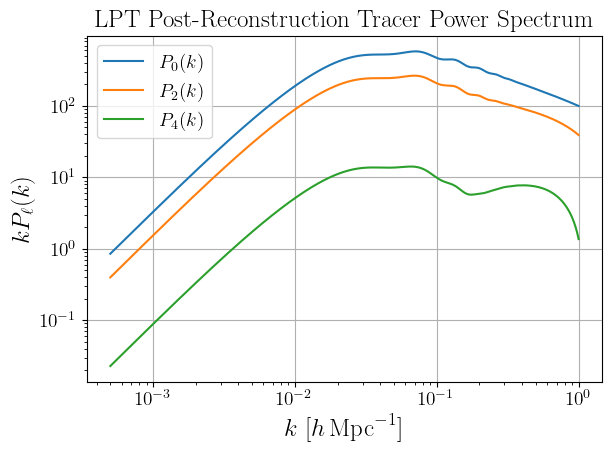

In [6]:
plt.loglog(klin,klin*Pkell0_lpt, label=fr"$P_0(k)$")
plt.loglog(klin,klin*Pkell2_lpt, label=fr"$P_2(k)$")
plt.loglog(klin,klin*Pkell4_lpt, label=fr"$P_4(k)$")
plt.xlabel(r"$k\ [h\,\mathrm{Mpc}^{-1}]$")
plt.ylabel(r"$kP_{\ell}(k)$")
plt.legend()
plt.title("LPT Post-Reconstruction Tracer Power Spectrum")
plt.grid(True)
plt.tight_layout()
plt.show()

### We compare to the linear theory multipoles which we obtain by first letting $P_\text{lin}(\mu,k)=(b+f\mu^2)^2P_\text{lin}(k)$ and then integrating over $\mu$.

In [7]:
def get_multipoles(pkmu, wmu):
    pkell = np.sum( pkmu * wmu[:, None,:], axis=-1)
    return pkell

def set_leggauss_mu_wmu(ells,mu=20):
    mulin, wmu = weights_leggauss(mu, sym=True)

    wmu = np.array([wmu * (2 * ell + 1) * special.legendre(ell)(mulin) for ell in ells])

    return wmu

def weights_leggauss(nx, sym=False):
    '''
    Copied from cosmodesi/desilike/utils.
    '''
    x, wx = np.polynomial.legendre.leggauss((1 + sym) * nx)
    if sym:
        x, wx = x[nx:], (wx[nx:] + wx[nx - 1::-1]) / 2.
    return x, wx

### Linear theory

In [8]:
mulin = forecast.mu.reshape((forecast.Nk,forecast.Nmu))[0,:]

plin = np.array([forecast.cosmo.pk_cb_lin(k*h,z)*h**3. for k in klin])

In [9]:
ells = [0,2,4]

wmu = set_leggauss_mu_wmu(ells, mu=50)

In [10]:
f = forecast.cosmo.scale_independent_growth_factor_f(z)

bias = b[0](z)

Pkmu_lin = ((bias+f*mulin**2)**2)[:, None] * plin[None,:]

Pkell_lin = get_multipoles(Pkmu_lin.T, wmu)

#Add N? for broadband term? idk.

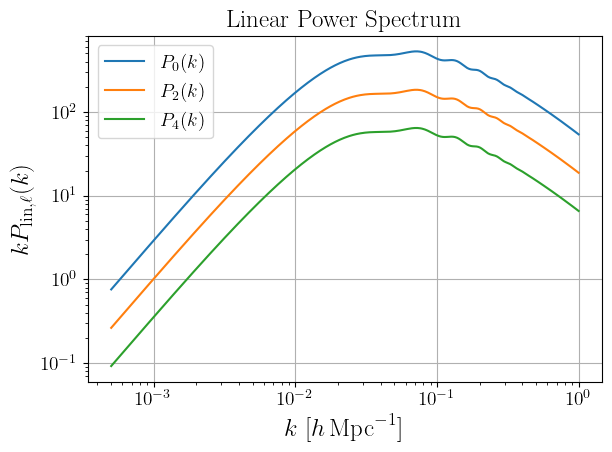

In [11]:
for i in range(len(ells)):
    plt.loglog(klin, klin*Pkell_lin[i], label=fr"$P_{{{ells[i]}}}(k)$")
plt.xlabel(r"$k\ [h\,\mathrm{Mpc}^{-1}]$")
plt.ylabel(r"$kP_{\mathrm{lin}, \ell}(k)$")
plt.legend()
plt.title("Linear Power Spectrum")
plt.grid(True)
plt.tight_layout()
plt.show()

### Pre-reconstruction

In [12]:
forecast.recon = False

_, Pkell0_prerecon, Pkell2_prerecon, Pkell4_prerecon = compute_tracer_power_spectrum(forecast, Xind=0, Yind=0, N=0, N2=0, N4=0, z=z, moments=True)

In [13]:
mask = (klin >= 1e-3) & (klin <= 0.4)

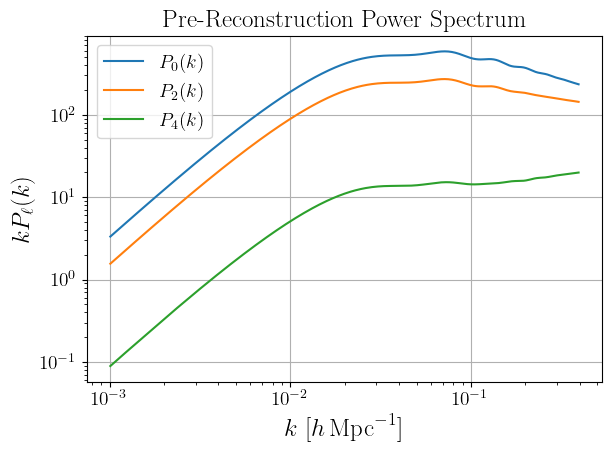

In [14]:
plt.loglog(klin[mask], (klin*Pkell0_prerecon)[mask], label=r'$P_0(k)$')
plt.loglog(klin[mask], (klin*Pkell2_prerecon)[mask], label=r'$P_2(k)$')
plt.loglog(klin[mask], (klin*Pkell4_prerecon)[mask], label=r'$P_4(k)$')
plt.xlabel(r"$k\ [h\,\mathrm{Mpc}^{-1}]$")
plt.ylabel(r"$kP_{\ell}(k)$")
plt.legend()
plt.title("Pre-Reconstruction Power Spectrum")
plt.grid(True)
plt.tight_layout()
plt.show()

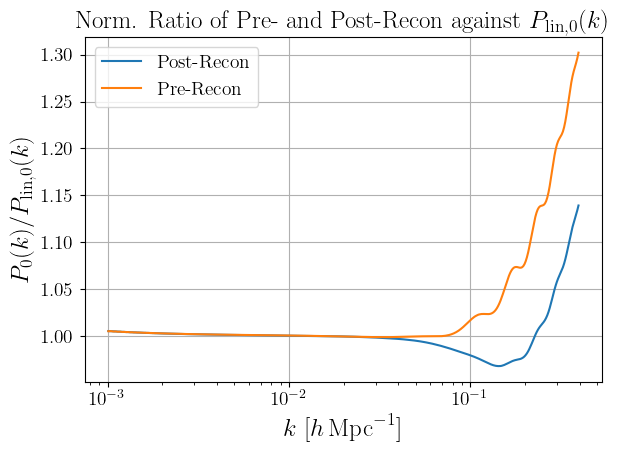

In [15]:
scale_recon = np.max(Pkell_lin[0]) / np.max(Pkell0_lpt)
scale_prerecon = np.max(Pkell_lin[0]) / np.max(Pkell0_prerecon)

plt.semilogx(klin[mask], (Pkell0_lpt * scale_recon / Pkell_lin[0])[mask] , label=fr"Post-Recon")
plt.semilogx(klin[mask], (Pkell0_prerecon * scale_prerecon / Pkell_lin[0])[mask], label='Pre-Recon')
#plt.semilogx(klin, P_lpt_2 * scale_1 / Pkell_lin[1], label=fr"$P_2(k)$")
#plt.semilogx(klin, P_lpt_4 * scale_2 / Pkell_lin[2], label=fr"$P_4(k)$")
plt.xlabel(r"$k\ [h\,\mathrm{Mpc}^{-1}]$")
plt.ylabel(r"$P_{0}(k)/P_{\mathrm{lin},0}(k)$")
plt.legend()
plt.title("Norm. Ratio of Pre- and Post-Recon against $P_{\mathrm{lin},0}(k)$")
plt.grid(True)
plt.tight_layout()
plt.show()

### The $\ell=0$ term matches Figure 2 of Stephen Chen's paper. $\ell = 2$ is okay too. $\ell=4$ is deeply concerning.

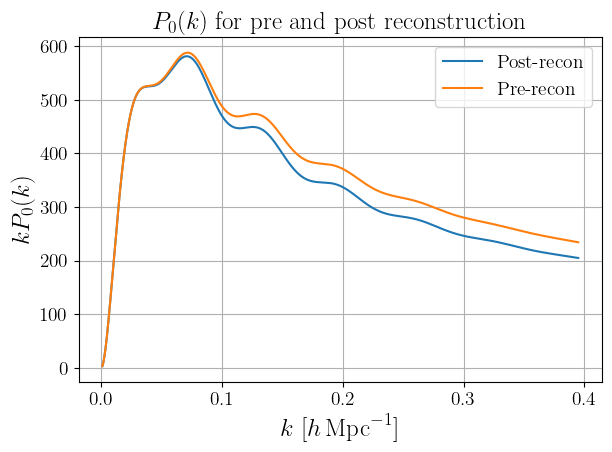

In [16]:
scale = np.max(Pkell0_prerecon) / np.max(Pkell0_lpt)

plt.plot(klin[mask], (klin* Pkell0_lpt*scale)[mask], label=r'Post-recon')
plt.plot(klin[mask], (klin* Pkell0_prerecon)[mask], label=r'Pre-recon')
plt.xlabel(r"$k\ [h\,\mathrm{Mpc}^{-1}]$")
plt.ylabel(r"$k P_{0}(k)$")
plt.legend()
plt.title("$P_0(k)$ for pre and post reconstruction")
plt.grid(True)
plt.tight_layout()
plt.show()

### We see that the pre and post-reconstruction power spectra agree at $k < 0.05$. At BAO scales, the post-reconstruction power spectrum has sharpened wiggles that manifest in the ratio. 

### We now perform the same plots with the new BAO reconstruction module. This module uses the same get_smoothed_p method as in MultiFishLSS (which uses a combination of the Eisenstein & Hu filter and the Savitsky-Golai filter), and with zero broadband spline. This will be updated to use the Wallisch 2018 filter and include the broadband spline.

In [54]:
%reload_ext autoreload
%autoreload 2

forecast.recon = 'wigglesplit'

Pkell0_wiggle, Pkell2_wiggle, Pkell4_wiggle = compute_tracer_power_spectrum(forecast, Xind=0, Yind=0, z=z, sigmaS=2., moments=True)

sigmas: 2.0 1.8958576477399534 0.9591770910140693
2.0 1.8958576477399534 0.9591770910140693
Using simpson integration


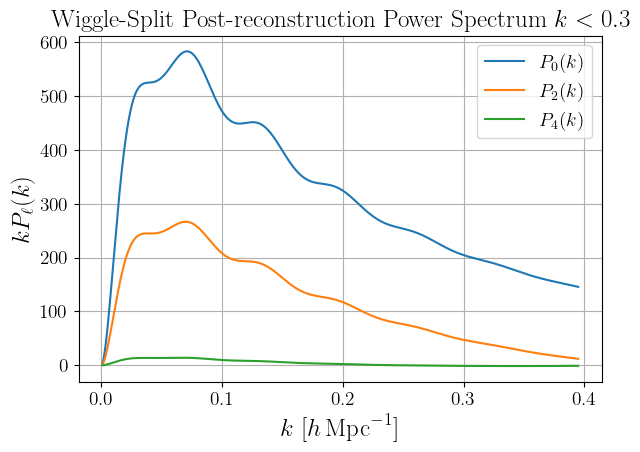

In [55]:
plt.plot(klin[mask], (klin*Pkell0_wiggle)[mask], label=r'$P_0(k)$')
plt.plot(klin[mask], (klin*Pkell2_wiggle)[mask], label=r'$P_2(k)$')
plt.plot(klin[mask], (klin*Pkell4_wiggle)[mask], label=r'$P_4(k)$')
plt.xlabel(r"$k\ [h\,\mathrm{Mpc}^{-1}]$")
plt.ylabel(r"$kP_{\ell}(k)$")
plt.legend()
plt.title("Wiggle-Split Post-reconstruction Power Spectrum $k<0.3$")
plt.grid(True)
plt.tight_layout()
plt.show()

In [56]:
print(Pkell0_wiggle)

[ 1689.77650049  1714.63860275  1739.85988306  1765.44523903
  1791.39962145  1817.72802729  1844.43551115  1871.52718736
  1899.00822796  1926.88384968  1955.15932339  1983.83998028
  2012.93121176  2042.43845724  2072.36720355  2102.7229975
  2133.51144674  2164.73821285  2196.40899803  2228.52956128
  2261.10572208  2294.14335839  2327.64838806  2361.62677762
  2396.08455305  2431.02779983  2466.4626489   2502.39526841
  2538.83188277  2575.7787745   2613.24227853  2651.22876022
  2689.7446331   2728.79636647  2768.39048412  2808.53354241
  2849.23213126  2890.49289261  2932.32252082  2974.72775067
  3017.71533823  3061.29208406  3105.4648372   3150.2404906
  3195.62595182  3241.62815796  3288.25408952  3335.51076921
  3383.4052434   3431.94457696  3481.13587183  3530.98626725
  3581.50291564  3632.69293983  3684.56348144  3737.12170989
  3790.37483397  3844.33016425  3898.99506826  3954.37694301
  4010.48317475  4067.32072717  4124.89627591  4183.21647191
  4242.28796565  4302.1178

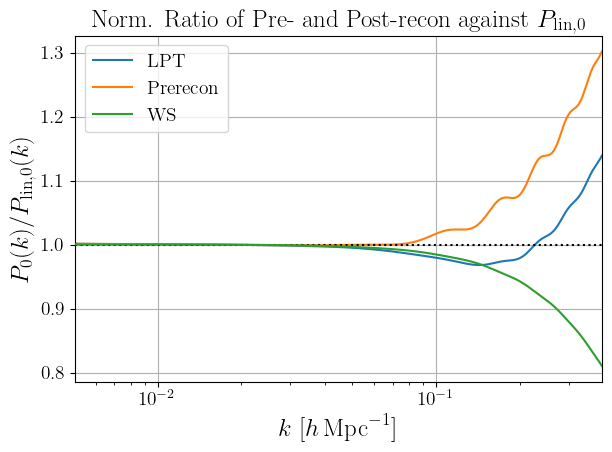

In [61]:
mask = (klin >= 5e-3) & (klin <= .4)
scale_lpt = np.max(Pkell_lin[0]) / np.max(Pkell0_lpt)
scale_prerecon = np.max(Pkell_lin[0]) / np.max(Pkell0_prerecon)
scale_ws = np.max(Pkell_lin[0]) / np.max(Pkell0_wiggle)

plt.semilogx(klin[mask], (Pkell0_lpt * scale_lpt / Pkell_lin[0])[mask] , label=fr"LPT")
plt.semilogx(klin[mask], (Pkell0_prerecon * scale_prerecon / Pkell_lin[0])[mask], label='Prerecon')
plt.semilogx(klin[mask], (Pkell0_wiggle * scale_ws / Pkell_lin[0])[mask], zorder=100, label=r'WS')
plt.semilogx(klin[mask], ( Pkell_lin[0]/ Pkell_lin[0])[mask], color='black', ls=':')
#plt.semilogx(klin, P_lpt_2 * scale_1 / Pkell_lin[1], label=fr"$P_2(k)$")
#plt.semilogx(klin, P_lpt_4 * scale_2 / Pkell_lin[2], label=fr"$P_4(k)$")
plt.xlabel(r"$k\ [h\,\mathrm{Mpc}^{-1}]$")
plt.ylabel(r"$P_{0}(k)/P_{\mathrm{lin},0}(k)$")
plt.legend()
plt.title("Norm. Ratio of Pre- and Post-recon against $P_{\mathrm{lin},0}$")
plt.grid(True)
plt.tight_layout()
ax = plt.gca()
ax.margins(x=0)
plt.savefig('/Users/makaibaker/Dropbox/2026/Berkeley/Research/recon_ratios.pdf')
plt.show()

### The two techniques, LPT and WS, when using the same broadband term (broadband polynomials using fiducial values of c_0 = N and c_i = 0, i.e. just adding N to the LPT and WS outputs) agrees in the broadband regime at low k because LPT breaks down at high k.

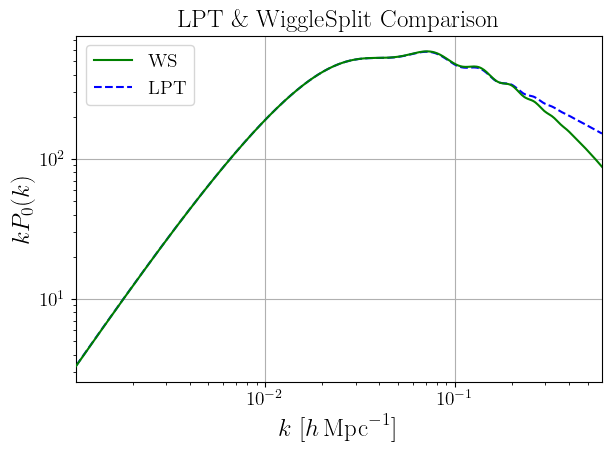

In [21]:
mask = (klin >= 1e-3) & (klin <= .6)
plt.loglog(klin[mask], (klin*Pkell0_wiggle)[mask], color='green', ls='-', zorder=99, label=r'WS')
plt.loglog(klin[mask], (klin*Pkell0_lpt)[mask] , color='blue', ls='--', label=r"LPT")
plt.xlabel(r"$k\ [h\,\mathrm{Mpc}^{-1}]$")
plt.ylabel(r"$kP_{0}(k)$")
plt.legend()
plt.title("LPT \& WiggleSplit Comparison")
plt.grid(True)
plt.tight_layout()
ax = plt.gca()
ax.margins(x=0)
plt.show()

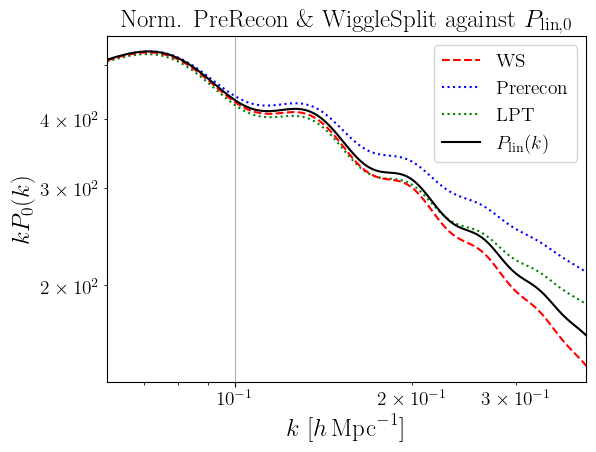

In [22]:
mask = (klin >= 6e-2) & (klin <= .4)

scale_ws = np.max(Pkell_lin[0]) / np.max(Pkell0_wiggle)
scale_prerecon = np.max(Pkell_lin[0]) / np.max(Pkell0_prerecon)
scale_lpt = np.max(Pkell_lin[0]) / np.max(Pkell0_lpt)

plt.loglog(klin[mask], (klin*Pkell0_wiggle * scale_ws )[mask], color='red', ls='--', zorder=99, label=r'WS')
plt.semilogx(klin[mask], (klin*Pkell0_prerecon * scale_prerecon )[mask], color='blue', ls=':', label='Prerecon')
plt.semilogx(klin[mask], (klin*Pkell0_lpt * scale_lpt )[mask] , color='green', ls=':', label=fr"LPT")
plt.loglog(klin[mask], (klin*Pkell_lin[0])[mask], color='black', zorder=100, label=r'$P_{\mathrm{lin}}(k)$')
plt.xlabel(r"$k\ [h\,\mathrm{Mpc}^{-1}]$")
plt.ylabel(r"$kP_{0}(k)$")
plt.legend()
plt.title("Norm. PreRecon \& WiggleSplit against $P_{\mathrm{lin},0}$")
plt.grid(True)
plt.tight_layout()
ax = plt.gca()
ax.margins(x=0)
plt.show()

### Above plot seems promising. Unsure why the LPT + Prerecon deviate from 1 at small k but WS is almost exactly 1.

#### The Wallish 2018 filter as implemented in DESI requires empirical knowledge of location of BAO bumps in k-space. 
#### I attempted an implementation but it didn't work particularly well. The currently implemented EH+ SavGol filter works better and is already implemented. Perhaps something to revisit.

In [23]:
from scipy.signal import savgol_filter


def get_smoothed_p_eh_savgol( fishcast,k,plin,division_factor=2.):
    '''
    Returns a power spectrum without wiggles, given by:
        P_nw = P_approx * F[P/P_approx]
    where P is the linear power spectrum, P_approx is given by Eisenstein & Hu (1998),
    and F is an SG low-pass filter.
    '''
    def Peh(k,p):
        '''
        Returns the smoothed power spectrum Eisenstein & Hu (1998).
        '''
        k = k.copy() * fishcast.params['h']
        Obh2      = fishcast.params['omega_b'] 
        Omh2      = fishcast.params['omega_b'] + fishcast.params['omega_cdm']
        f_baryon  = Obh2 / Omh2
        theta_cmb = fishcast.cosmo_fid.T_cmb() / 2.7
        k_eq = 0.0746 * Omh2 * theta_cmb ** (-2)
        sound_horizon = fishcast.params['h'] * 44.5 * np.log(9.83/Omh2) / \
                                np.sqrt(1 + 10 * Obh2** 0.75) 
        alpha_gamma = 1 - 0.328 * np.log(431*Omh2) * f_baryon + \
                    0.38* np.log(22.3*Omh2) * f_baryon ** 2
        ks = k * sound_horizon / fishcast.params['h']
        q = k / (13.41*k_eq)
        gamma_eff = Omh2 * (alpha_gamma + (1 - alpha_gamma) / (1 + (0.43*ks) ** 4))
        q_eff = q * Omh2 / gamma_eff
        L0 = np.log(2*np.e + 1.8 * q_eff)
        C0 = 14.2 + 731.0 / (1 + 62.5 * q_eff)
        Teh = L0 / (L0 + C0 * q_eff**2)
        t_with_wiggles = np.sqrt(p/k**fishcast.params['n_s'])
        t_with_wiggles /= t_with_wiggles[0]
        return p * (Teh/t_with_wiggles)**2.

    p_approx = Peh(k,plin)
    psmooth = savgol_filter(plin/p_approx,int(fishcast.Nk/division_factor)+1-\
                                            int(fishcast.Nk/division_factor)%2, 6)*p_approx
    return psmooth

In [24]:
P_nw = get_smoothed_p_eh_savgol(forecast, klin, Pkell_lin[0])

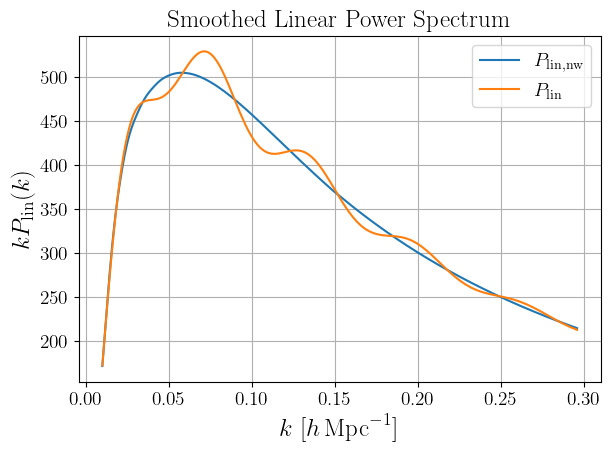

In [25]:
mask = (klin >= 1e-2) & (klin <= .3)

plt.plot(klin[mask], (klin*P_nw)[mask], label='$P_\mathrm{lin, nw}$')
plt.plot(klin[mask], (klin*Pkell_lin[0])[mask], label='$P_\mathrm{lin}$')
plt.xlabel(r"$k\ [h\,\mathrm{Mpc}^{-1}]$")
plt.ylabel(r"$kP_{\mathrm{lin}}(k)$")
plt.legend()
plt.title("Smoothed Linear Power Spectrum")
plt.grid(True)
plt.tight_layout()
plt.show()

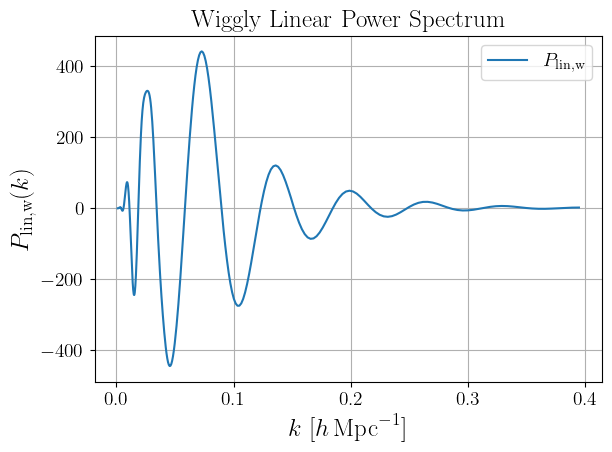

In [26]:
mask = (klin >= 1e-3) & (klin <=.4 )

wig = Pkell_lin[0] - P_nw 

plt.plot(klin[mask], wig[mask], label='$P_\mathrm{lin, w}$')

plt.xlabel(r"$k\ [h\,\mathrm{Mpc}^{-1}]$")
plt.ylabel(r"$P_{\mathrm{lin, w}}(k)$")
plt.legend()
plt.title("Wiggly Linear Power Spectrum")
plt.grid(True)
plt.tight_layout()
plt.show()

### Below, we see that for D_\ell(k>0) = 1 we must have the number of a_\ell per \ell be >= 20. So 60 spline amplitudes. 
### We can either: set D_\ell = 1 in twoPoint.py by hardcoding using 60 spline amplitudes, or use however many spline amplitudes as we want but actually add D_\ell as evaluated in fisherForecast.py to the recon power spectrum in twoPoint.py.

In [27]:
def W3(x):
    """
    W3 is the piecewise cubic spline (4th-order) extension of the counts-in-cell interpolation kernel (Hockney & Eastwood 1988; Jeong 2010).
    """
    absx = np.abs(x)

    ret = np.zeros_like(absx, dtype=float)

    #region 1
    mask1 = absx <= 1
    ret[mask1] = 4 - 6 * absx[mask1]**2  + 3 * absx[mask1]**3 
    
    #region 2
    mask2 = (absx > 1) & (absx <=2)
    ret[mask2] = 8 - 12 * absx[mask2]  + 6 * absx[mask2]**2 - absx[mask2]**3 

    return 1./6. * ret

In [28]:
def initialise_splines(forecast, N_splines, Pnw_interp, delta=0.06):
    """
    Initiialise the broadband splines. For broadband term 
    
    D_ell = \sum_{n=-1} ^ {N_\max} a_{\ell, n} W3(k/\delta - n)

    We have that for fiducial values of a_{\ell, n} = 1 (our choice), 

    D_0 = D_2 = D_4 = \sum_{n=-1} ^ {N_\max} W3(k/\delta - n)

    And dP/da_{\ell,n} = W3(n)*\mathcal{L}_\ell(\mu) 
    
    So the derivative for all ell is same as adding 
    
    D_0 * ( \mathcal{L}_0(\mu) + \mathcal{L}_2(\mu) + \mathcal{L}_4(\mu) ).

    We keep the values as an n by mu*k array so we can use it for derivatives (access each n)
    and for the broadband term in wiggle_split_recon (sum array along n).
    """
    arr = np.zeros( (N_splines, forecast.Nk) )

    k = forecast.k.reshape((forecast.Nk,forecast.Nmu))[:,0]

    for n in range(N_splines):
        pivot = n*delta  
        arr[n] = Pnw_interp(pivot)/W3(pivot)*W3(k/delta - (n-1))

    return arr

### Now plot sum of splines compared to $\ell=0$ multipole.

In [29]:
from scipy.interpolate import CubicSpline

Pnwinterp = CubicSpline(klin, P_nw)

N_splines = 8

spline_arr = initialise_splines(forecast, N_splines, Pnwinterp)

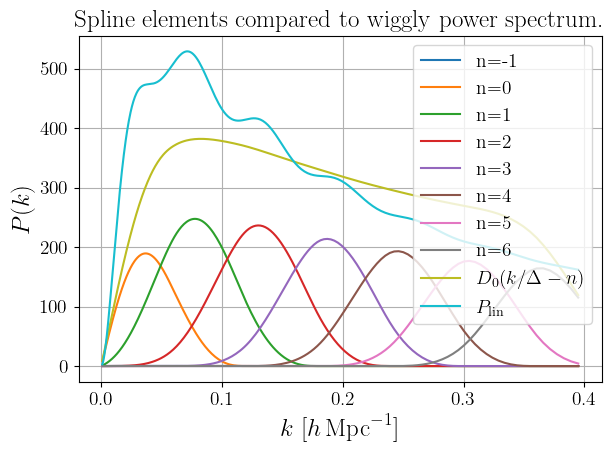

In [30]:
for i in range(N_splines):
    plt.plot(klin[mask], (klin*spline_arr[i])[mask], label='n={}'.format(i-1))

plt.plot(klin[mask], (klin*np.sum(spline_arr, axis=0))[mask], label=r'$D_0(k/\Delta-n)$')
plt.plot(klin[mask], (klin*Pkell_lin[0])[mask], label='$P_\mathrm{lin}$')
plt.xlabel(r"$k\ [h\,\mathrm{Mpc}^{-1}]$")
plt.ylabel(r"$P(k)$")
plt.legend()
plt.title("Spline elements compared to wiggly power spectrum.")
plt.grid(True)
plt.tight_layout()
plt.show()

### Perform Fisher forecast using polys and wigglesplit. "Verified" wigglesplit works in above tests, so the next minimal step is to use the currently implemented polys machinery with wigglsplit.

In [31]:
forecast.recon = 'LPT'
forecast.broadband = 'polys'
forecast.N_polys = 15

basis = np.array(['alpha_perp','alpha_parallel','b'])

forecast.free_params = basis
forecast.compute_derivatives() # will not overwrite unless specified

param in kwargs
2.5
sigmas: 2.0 1.7651239328606405 0.891270828930937
sigmas: 2.0 1.7651239328606405 0.891270828930937
sigmas: 2.0 1.7651239328606405 0.891270828930937


KeyboardInterrupt: 

In [ ]:
derivs = forecast.load_derivatives(basis)
F = lambda i: forecast.gen_fisher(basis, 100, derivatives=derivs, zbins=np.array([i]))
Fs = [F(i) for i in range(nbins)]
Fs = np.array(Fs)

In [ ]:
Finvs = [np.linalg.inv(Fs[i]) for i in range(nbins)]
saperp = [np.sqrt(Finvs[i][0,0]) for i in range(nbins)]
saparr = [np.sqrt(Finvs[i][1,1]) for i in range(nbins)]
print('Relative error on DA/rd:',saperp)
print('Relative error on H*rd:',saparr)


Relative error on DA/rd: [np.float64(0.0036029260662505196), np.float64(0.0036182888813548523)]
Relative error on H*rd: [np.float64(0.007066374071572658), np.float64(0.006977351386358036)]


### Now we want to verify that the numerical differentiation of P w.r.t. $\Sigma_{||}$ is correct by comparing to analytical prediction.